In [1]:
import pandas as pd
import numpy as np

In [4]:
investors = pd.read_csv("investors.csv")

transactions = pd.read_excel("transactions.xlsx")

In [5]:
investors.head()

,investor_id,name,city
0,1,Neha Gupta,Pune
1,2,Arjun Gupta,Mumbai
2,3,Amit Patel,Pune
3,4,Priya Patel,Ahmedabad
4,5,Pooja Singh,Ahmedabad


In [6]:
transactions.head()

,transaction_id,investor_id,stock,amount,date
0,1,30,ICICI,63152,2024-05-22
1,2,34,ICICI,54783,2024-06-23
2,3,37,INFY,92559,2024-02-24
3,4,26,ICICI,10476,2024-04-29
4,5,76,ICICI,66712,2024-03-12


In [7]:
print("Investors shape:", investors.shape)
print("Transactions shape:", transactions.shape)

Investors shape: (100, 3)
Transactions shape: (100, 5)


In [8]:
investors.isnull().sum()

investor_id    0
name           0
city           0
dtype: int64

In [9]:
transactions.isnull().sum()

transaction_id    0
investor_id       0
stock             0
amount            0
date              0
dtype: int64

In [10]:
merged_data = pd.merge(transactions, investors, on="investor_id")

In [11]:
merged_data.head()

,transaction_id,investor_id,stock,amount,date,name,city
0,1,30,ICICI,63152,2024-05-22,Vikram Patel,Ahmedabad
1,2,34,ICICI,54783,2024-06-23,Amit Desai,Bangalore
2,89,34,TCS,77800,2024-03-01,Amit Desai,Bangalore
3,3,37,INFY,92559,2024-02-24,Anjali Singh,Chennai
4,23,37,TCS,82915,2024-06-03,Anjali Singh,Chennai


In [12]:
merged_data["investment_value"] = merged_data["amount"] * 1.05

In [13]:
merged_data.head()

,transaction_id,investor_id,stock,amount,date,name,city,investment_value
0,1,30,ICICI,63152,2024-05-22,Vikram Patel,Ahmedabad,66309.60
1,2,34,ICICI,54783,2024-06-23,Amit Desai,Bangalore,57522.15
2,89,34,TCS,77800,2024-03-01,Amit Desai,Bangalore,81690.00
3,3,37,INFY,92559,2024-02-24,Anjali Singh,Chennai,97186.95
4,23,37,TCS,82915,2024-06-03,Anjali Singh,Chennai,87060.75


In [14]:
merged_data.groupby("stock")["amount"].sum()

stock
HCL          685513
HDFC        1001006
ICICI        802308
INFY         968729
RELIANCE     630225
TCS          474110
WIPRO        654372
Name: amount, dtype: int64

In [15]:
merged_data.groupby("name")["amount"].sum().sort_values(ascending=False).head(10)

name
Anjali Singh    428762
Sneha Sharma    305141
Amit Patel      300291
Arjun Patel     270303
Pooja Singh     267432
Arjun Desai     245247
Anjali Gupta    234871
Priya Singh     209961
Neha Singh      209843
Priya Sharma    194018
Name: amount, dtype: int64

In [16]:
merged_data["amount"].sum()

5216263

In [17]:
merged_data.groupby("stock")["amount"].sum().sort_values(ascending=False)

stock
HDFC        1001006
INFY         968729
ICICI        802308
HCL          685513
WIPRO        654372
RELIANCE     630225
TCS          474110
Name: amount, dtype: int64

In [18]:
merged_data.groupby("city")["amount"].sum().sort_values(ascending=False)

city
Ahmedabad    1064958
Hyderabad     809913
Delhi         809615
Bangalore     781587
Pune          674463
Chennai       602194
Mumbai        473533
Name: amount, dtype: int64

In [19]:
merged_data.groupby("name")["amount"].sum().sort_values(ascending=False).head(10)

name
Anjali Singh    428762
Sneha Sharma    305141
Amit Patel      300291
Arjun Patel     270303
Pooja Singh     267432
Arjun Desai     245247
Anjali Gupta    234871
Priya Singh     209961
Neha Singh      209843
Priya Sharma    194018
Name: amount, dtype: int64

<AxesSubplot:title={'center':'Investment by Stock'}, xlabel='stock'>

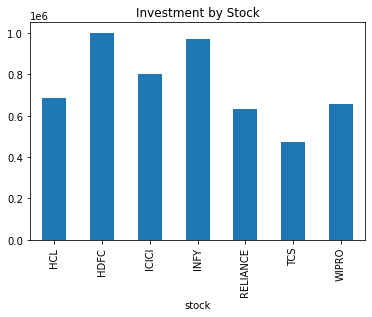

In [20]:
merged_data.groupby("stock")["amount"].sum().plot(kind="bar", title="Investment by Stock")

<AxesSubplot:title={'center':'Investment by City'}, xlabel='city'>

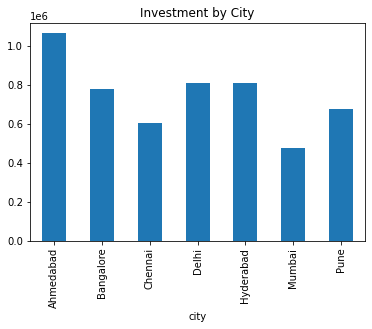

In [21]:
merged_data.groupby("city")["amount"].sum().plot(kind="bar", title="Investment by City")

<AxesSubplot:title={'center':'Investment Trend'}, xlabel='date'>

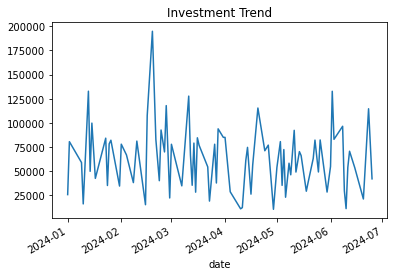

In [22]:
merged_data.groupby("date")["amount"].sum().plot(title="Investment Trend")

In [23]:
merged_data.to_csv("processed_investor_data.csv", index=False)

In [24]:
import os
os.listdir()

['.ipynb_checkpoints',
 'investors.csv',
 'investor_etl_pipeline.ipynb',
 'processed_investor_data.csv',
 'transactions.xlsx']

In [25]:
import pandas as pd

df = pd.read_csv("processed_investor_data.csv")

df.head()

,transaction_id,investor_id,stock,amount,date,name,city,investment_value
0,1,30,ICICI,63152,2024-05-22,Vikram Patel,Ahmedabad,66309.60
1,2,34,ICICI,54783,2024-06-23,Amit Desai,Bangalore,57522.15
2,89,34,TCS,77800,2024-03-01,Amit Desai,Bangalore,81690.00
3,3,37,INFY,92559,2024-02-24,Anjali Singh,Chennai,97186.95
4,23,37,TCS,82915,2024-06-03,Anjali Singh,Chennai,87060.75


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    100 non-null    int64  
 1   investor_id       100 non-null    int64  
 2   stock             100 non-null    object 
 3   amount            100 non-null    int64  
 4   date              100 non-null    object 
 5   name              100 non-null    object 
 6   city              100 non-null    object 
 7   investment_value  100 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 6.4+ KB


In [27]:
city_investment = df.groupby("city")["amount"].sum()

city_investment

city
Ahmedabad    1064958
Bangalore     781587
Chennai       602194
Delhi         809615
Hyderabad     809913
Mumbai        473533
Pune          674463
Name: amount, dtype: int64

In [28]:
stock_investment = df.groupby("stock")["amount"].sum()

stock_investment

stock
HCL          685513
HDFC        1001006
ICICI        802308
INFY         968729
RELIANCE     630225
TCS          474110
WIPRO        654372
Name: amount, dtype: int64

In [29]:
top_investors = df.groupby("name")["amount"].sum().sort_values(ascending=False)

top_investors.head(10)

name
Anjali Singh    428762
Sneha Sharma    305141
Amit Patel      300291
Arjun Patel     270303
Pooja Singh     267432
Arjun Desai     245247
Anjali Gupta    234871
Priya Singh     209961
Neha Singh      209843
Priya Sharma    194018
Name: amount, dtype: int64

In [30]:
import matplotlib.pyplot as plt

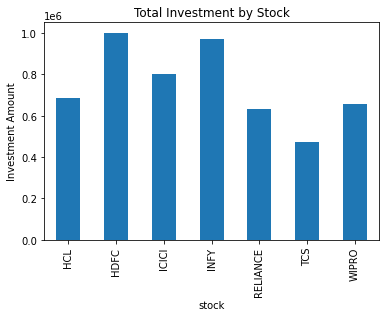

In [31]:
stock_investment.plot(kind="bar")

plt.title("Total Investment by Stock")
plt.ylabel("Investment Amount")
plt.show()

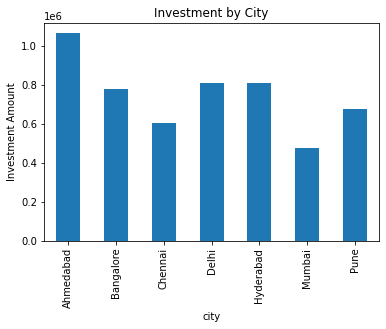

In [32]:
city_investment.plot(kind="bar")

plt.title("Investment by City")
plt.ylabel("Investment Amount")
plt.show()

In [33]:
city_investment.to_csv("city_investment_summary.csv")
stock_investment.to_csv("stock_investment_summary.csv")

In [36]:
def run_pipeline():

    investors = pd.read_csv("investors.csv")
    transactions = pd.read_excel("transactions.xlsx")

    merged = pd.merge(transactions, investors, on="investor_id")

    merged.to_csv("processed_investor_data.csv", index=False)

    city_investment = merged.groupby("city")["amount"].sum()
    stock_investment = merged.groupby("stock")["amount"].sum()

    city_investment.to_csv("city_investment_summary.csv")
    stock_investment.to_csv("stock_investment_summary.csv")

run_pipeline()

In [37]:
!pip install mysql-connector-python

In [38]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="More@123"
)

cursor = conn.cursor()

print("Connected to MySQL")

Connected to MySQL


In [39]:
cursor.execute("CREATE DATABASE investor_db")

In [40]:
cursor.execute("USE investor_db")

In [41]:
create_table_query = """
CREATE TABLE investor_transactions (
    investor_id INT,
    name VARCHAR(100),
    city VARCHAR(100),
    stock VARCHAR(50),
    amount FLOAT
)
"""

cursor.execute(create_table_query)

In [42]:
import pandas as pd

df = pd.read_csv("processed_investor_data.csv")

In [43]:
for index, row in df.iterrows():
    cursor.execute(
        "INSERT INTO investor_transactions VALUES (%s,%s,%s,%s,%s)",
        (row['investor_id'], row['name'], row['city'], row['stock'], row['amount'])
    )

conn.commit()

In [44]:
cursor.execute("SELECT * FROM investor_transactions LIMIT 5")

for row in cursor.fetchall():
    print(row)

(30, 'Vikram Patel', 'Ahmedabad', 'ICICI', 63152.0)
(34, 'Amit Desai', 'Bangalore', 'ICICI', 54783.0)
(34, 'Amit Desai', 'Bangalore', 'TCS', 77800.0)
(37, 'Anjali Singh', 'Chennai', 'INFY', 92559.0)
(37, 'Anjali Singh', 'Chennai', 'TCS', 82915.0)


In [45]:
query = """
SELECT city, SUM(amount)
FROM investor_transactions
GROUP BY city
"""

cursor.execute(query)

for row in cursor.fetchall():
    print(row)

('Ahmedabad', 1064958.0)
('Bangalore', 781587.0)
('Chennai', 602194.0)
('Mumbai', 473533.0)
('Hyderabad', 809913.0)
('Pune', 674463.0)
('Delhi', 809615.0)


In [46]:
cursor.execute("SELECT * FROM investor_transactions LIMIT 5")

for row in cursor.fetchall():
    print(row)

(30, 'Vikram Patel', 'Ahmedabad', 'ICICI', 63152.0)
(34, 'Amit Desai', 'Bangalore', 'ICICI', 54783.0)
(34, 'Amit Desai', 'Bangalore', 'TCS', 77800.0)
(37, 'Anjali Singh', 'Chennai', 'INFY', 92559.0)
(37, 'Anjali Singh', 'Chennai', 'TCS', 82915.0)


In [47]:
query = """
SELECT city, SUM(amount)
FROM investor_transactions
GROUP BY city
"""

cursor.execute(query)

for row in cursor.fetchall():
    print(row)

('Ahmedabad', 1064958.0)
('Bangalore', 781587.0)
('Chennai', 602194.0)
('Mumbai', 473533.0)
('Hyderabad', 809913.0)
('Pune', 674463.0)
('Delhi', 809615.0)
